# MCS, scheduler, and RX-probability correction

This notebook demonstrates the radio-path corrections using the active simulator:

1. the selected MCS now uses its own nominal rate;
2. RX probability is evaluated on the actual PRB indices allocated to the UE;
3. an unscheduled UE is reported as `transmission_attempted=False` and `rx_probability=NaN`, not as a radio failure with probability zero;
4. `effective_sinr_db` exposes the SINR used by the MCS response curve.

## 1. Imports and configuration

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl-mcs-rx')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from channel_models import MCSCodeset
from tests.test_single_ue_handover import _make_env

N_STEPS = 3000
HIGH_SINR_DB = 15.0
TARGET_RX_PROBABILITY = 0.90
print('Project root:', ROOT)

Project root: /home/oussama/Desktop/chech


## 2. MCS and nominal-rate consistency

The old preliminary-selection path could return MCS $m-1$ while using the nominal rate of MCS $m$. The table below verifies that every selected MCS now matches the returned bits-per-symbol value.

In [2]:
codeset = MCSCodeset()
mcs_rows = []
for sinr_db in np.arange(-5.0, 31.0, 1.0):
    selected_mcs, returned_rate = codeset.mcs_rate_vs_error(sinr_db, 0.1)
    nominal_rate = codeset.nominal_rate(selected_mcs)
    mcs_rows.append({
        'sinr_db': sinr_db,
        'selected_mcs': selected_mcs,
        'returned_rate': returned_rate,
        'selected_mcs_nominal_rate': nominal_rate,
        'rate_error': returned_rate - nominal_rate,
        'predicted_rx_probability': float(codeset.estimate_rx_prob(selected_mcs, sinr_db)),
    })

mcs_check = pd.DataFrame(mcs_rows)
display(mcs_check)
assert np.allclose(mcs_check['rate_error'], 0.0)
print('PASS: every selected MCS uses its own nominal rate.')

,sinr_db,selected_mcs,returned_rate,selected_mcs_nominal_rate,rate_error,predicted_rx_probability
0,-5.0,0,0.400000,0.400000,0.0,4.150654e-09
1,-4.0,0,0.400000,0.400000,0.0,1.237277e-05
2,-3.0,0,0.400000,0.400000,0.0,3.557119e-02
3,-2.0,0,0.400000,0.400000,0.0,9.909867e-01
4,-1.0,0,0.400000,0.400000,0.0,9.999969e-01
5,0.0,2,0.666667,0.666667,0.0,9.959299e-01
6,1.0,3,0.800000,0.800000,0.0,9.998334e-01
7,2.0,4,1.000000,1.000000,0.0,9.909867e-01
8,3.0,4,1.000000,1.000000,0.0,9.999969e-01
9,4.0,6,1.333333,1.333333,0.0,9.801597e-01


PASS: every selected MCS uses its own nominal rate.


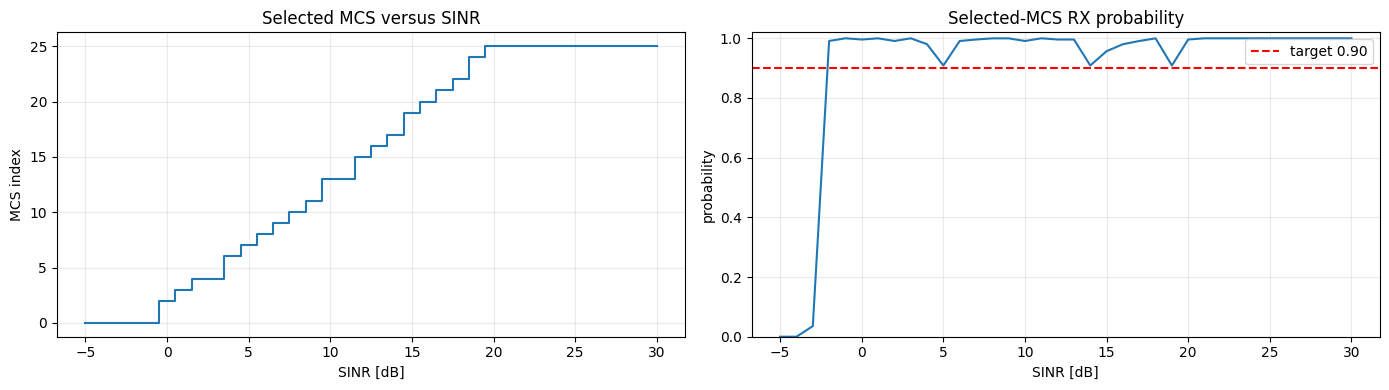

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].step(mcs_check['sinr_db'], mcs_check['selected_mcs'], where='mid')
axes[0].set(title='Selected MCS versus SINR', xlabel='SINR [dB]', ylabel='MCS index')
axes[1].plot(mcs_check['sinr_db'], mcs_check['predicted_rx_probability'])
axes[1].axhline(TARGET_RX_PROBABILITY, color='red', linestyle='--', label='target 0.90')
axes[1].set(title='Selected-MCS RX probability', xlabel='SINR [dB]', ylabel='probability', ylim=(0, 1.02))
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Run the real moving-UE radio trace

The scenario contains one moving eMBB UE and three gNBs. It exercises traffic generation, PF scheduling, frequency-selective fading, MCS selection, packet reception, and A3 handover.

In [4]:
env, ue_id = _make_env()
trace_rows = []
try:
    for step in range(N_STEPS):
        env.step(0)
        radio = env.get_ue_radio_metrics(ue_id)
        trace_rows.append({'step': step, **radio})
finally:
    env.close()

trace = pd.DataFrame(trace_rows)
print('Rows:', len(trace))
display(trace.head())

Rows: 3000


,step,ue_id,serving_gnb,connected,x,y,vx,vy,queue,throughput,...,rsrp_dbm,rssi_dbm,rsrq_db,noise_dbm,interference_dbm,target_gnb,ho_pending,ho_candidate,ho_counter,environment_loss_db
0,0,0,0,True,50.15,0.0,150.0,0.0,0.0,0.00,...,-54.090948,-54.089000,19.998052,-114.447275,-87.581076,NaN,False,None,0,0.0
1,1,0,0,True,50.30,0.0,150.0,0.0,0.0,60000.00,...,-54.139717,-54.137745,19.998028,-114.447275,-87.577055,NaN,False,None,0,0.0
2,2,0,0,True,50.45,0.0,150.0,0.0,0.0,118800.00,...,-54.188341,-54.186345,19.998004,-114.447275,-87.573033,NaN,False,None,0,0.0
3,3,0,0,True,50.60,0.0,150.0,0.0,0.0,116424.00,...,-54.236820,-54.234800,19.997980,-114.447275,-87.569009,NaN,False,None,0,0.0
4,4,0,0,True,50.75,0.0,150.0,0.0,0.0,174095.52,...,-54.285156,-54.283112,19.997955,-114.447275,-87.564985,NaN,False,None,0,0.0


## 4. Old interpretation versus corrected interpretation

The old metric treated an unscheduled row as `rx_probability=0`. The `old_rx_probability` column below reconstructs that behavior. The corrected metric keeps such rows as `NaN`, because no decoding attempt occurred.

In [5]:
trace['old_rx_probability'] = trace['rx_probability'].fillna(0.0)
high = trace[trace['sinr_db'] > HIGH_SINR_DB].copy()
high_scheduled = high[high['transmission_attempted']].copy()
high_unscheduled = high[~high['transmission_attempted']].copy()

comparison = pd.DataFrame([
    {
        'metric': 'Old: all high-SINR rows, unscheduled=0',
        'rows': len(high),
        'mean_rx_probability': high['old_rx_probability'].mean(),
        'minimum_rx_probability': high['old_rx_probability'].min(),
    },
    {
        'metric': 'Corrected: scheduled high-SINR rows only',
        'rows': len(high_scheduled),
        'mean_rx_probability': high_scheduled['rx_probability'].mean(),
        'minimum_rx_probability': high_scheduled['rx_probability'].min(),
    },
])
display(comparison)
print('High-SINR unscheduled rows:', len(high_unscheduled))
print('All unscheduled RX values are NaN:', high_unscheduled['rx_probability'].isna().all())

,metric,rows,mean_rx_probability,minimum_rx_probability
0,"Old: all high-SINR rows, unscheduled=0",1446,0.713789,0.000000
1,Corrected: scheduled high-SINR rows only,1040,0.992441,0.901386


High-SINR unscheduled rows: 406
All unscheduled RX values are NaN: True


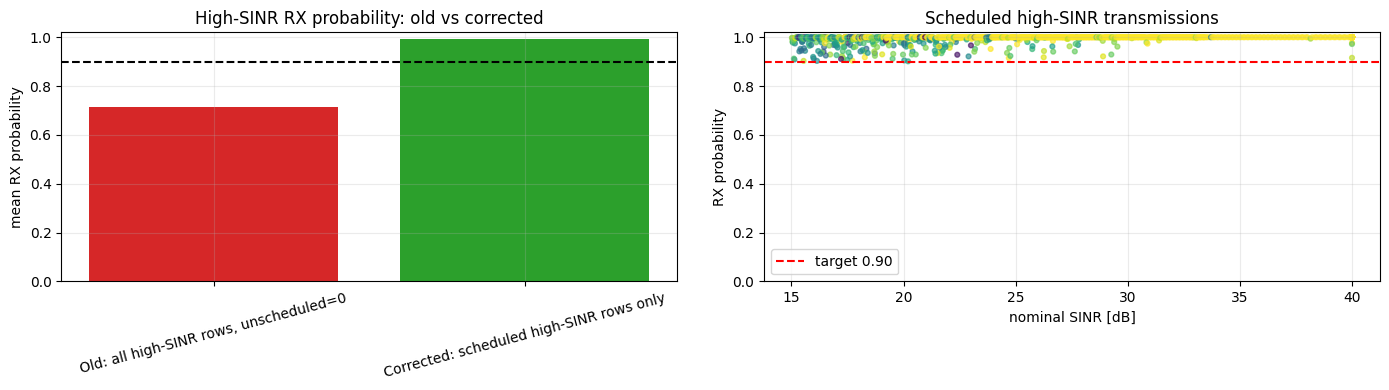

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(comparison['metric'], comparison['mean_rx_probability'], color=['tab:red', 'tab:green'])
axes[0].axhline(TARGET_RX_PROBABILITY, color='black', linestyle='--')
axes[0].set(title='High-SINR RX probability: old vs corrected', ylabel='mean RX probability', ylim=(0, 1.02))
axes[0].tick_params(axis='x', rotation=15)

axes[1].scatter(
    high_scheduled['sinr_db'],
    high_scheduled['rx_probability'],
    c=high_scheduled['mcs'],
    cmap='viridis',
    s=12,
    alpha=0.65,
)
axes[1].axhline(TARGET_RX_PROBABILITY, color='red', linestyle='--', label='target 0.90')
axes[1].set(title='Scheduled high-SINR transmissions', xlabel='nominal SINR [dB]', ylabel='RX probability', ylim=(0, 1.02))
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Nominal SINR, effective SINR, MCS, and allocated PRBs

`sinr_db` is the nominal scalar link SINR. `effective_sinr_db` is calculated from the actual allocated PRBs and is the value used by the selected MCS response curve.

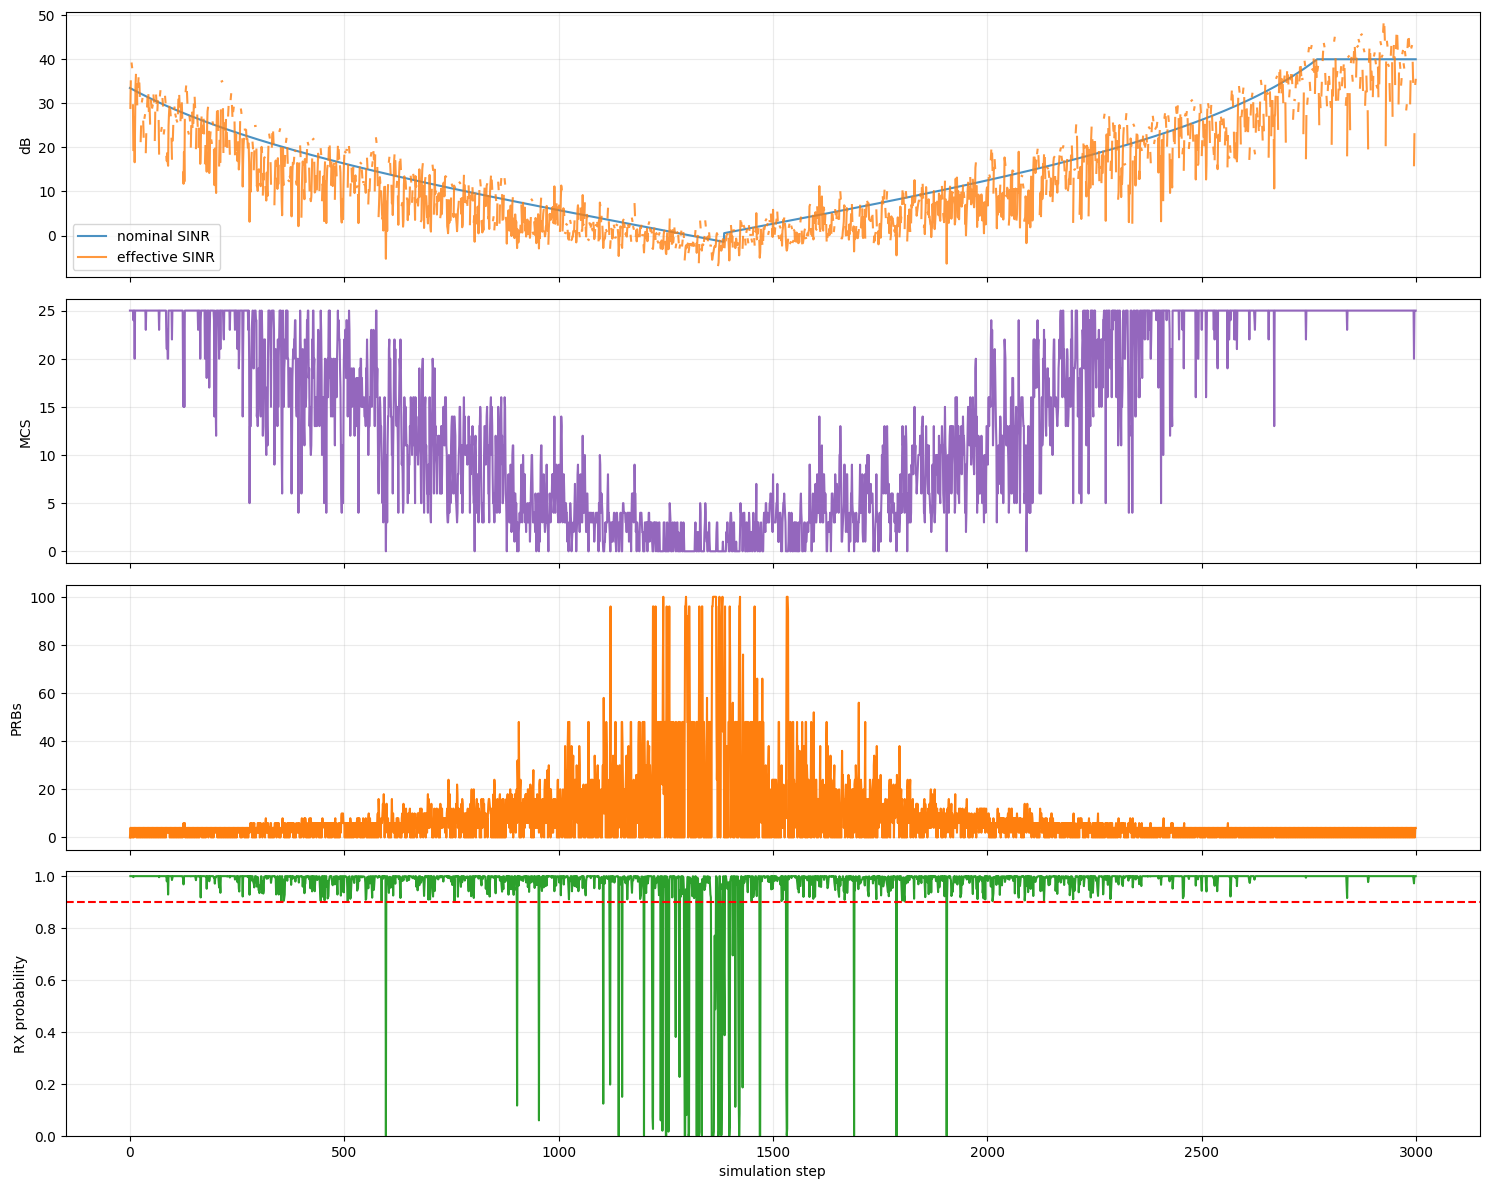

In [7]:
scheduled = trace[trace['transmission_attempted']].copy()
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
axes[0].plot(trace['step'], trace['sinr_db'], label='nominal SINR', alpha=0.8)
axes[0].plot(trace['step'], trace['effective_sinr_db'], label='effective SINR', alpha=0.8)
axes[0].set_ylabel('dB'); axes[0].legend()
axes[1].plot(trace['step'], trace['mcs'], color='tab:purple'); axes[1].set_ylabel('MCS')
axes[2].plot(trace['step'], trace['allocated_prbs'], color='tab:orange'); axes[2].set_ylabel('PRBs')
axes[3].plot(scheduled['step'], scheduled['rx_probability'], color='tab:green')
axes[3].axhline(TARGET_RX_PROBABILITY, color='red', linestyle='--')
axes[3].set(ylabel='RX probability', xlabel='simulation step', ylim=(0, 1.02))
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. SINR-binned scheduled reliability

Only rows with an actual transmission attempt are included.

,rows,mean_nominal_sinr,mean_effective_sinr,mean_mcs,mean_prbs,mean_rx_probability,minimum_rx_probability
sinr_bin,,,,,,,
"(-100, 0]",61,-0.765704,-1.839897,0.754098,60.196721,0.690798,5.029705e-15
"(0, 5]",386,2.634675,0.623317,2.608808,34.041451,0.903268,2.332028e-11
"(5, 10]",414,7.493487,3.956162,5.920290,15.570048,0.977252,2.448872e-07
"(10, 15]",387,12.425378,8.677831,11.105943,8.310078,0.981310,6.844449e-14
"(15, 20]",295,17.400679,14.754002,17.979661,5.688136,0.985003,9.030169e-01
"(20, 25]",241,22.333540,19.355132,21.414938,4.240664,0.990203,9.013860e-01
"(25, 30]",182,27.372365,23.764321,24.049451,3.901099,0.995258,9.178198e-01
"(30, 41]",322,36.722811,33.387497,24.872671,3.987578,0.999337,9.155870e-01


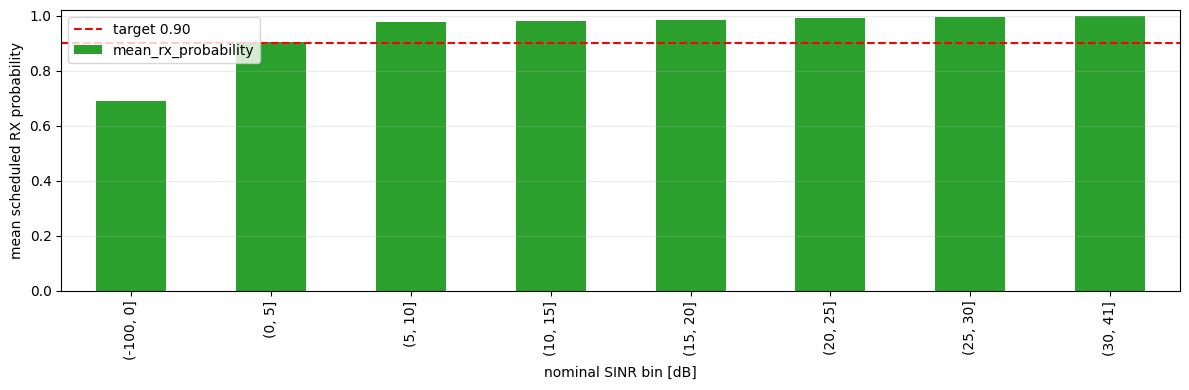

In [8]:
bins = [-100, 0, 5, 10, 15, 20, 25, 30, 41]
scheduled['sinr_bin'] = pd.cut(scheduled['sinr_db'], bins=bins)
rx_by_sinr = scheduled.groupby('sinr_bin', observed=True).agg(
    rows=('rx_probability', 'size'),
    mean_nominal_sinr=('sinr_db', 'mean'),
    mean_effective_sinr=('effective_sinr_db', 'mean'),
    mean_mcs=('mcs', 'mean'),
    mean_prbs=('allocated_prbs', 'mean'),
    mean_rx_probability=('rx_probability', 'mean'),
    minimum_rx_probability=('rx_probability', 'min'),
)
display(rx_by_sinr)

rx_by_sinr['mean_rx_probability'].plot.bar(figsize=(12, 4), color='tab:green')
plt.axhline(TARGET_RX_PROBABILITY, color='red', linestyle='--', label='target 0.90')
plt.ylabel('mean scheduled RX probability')
plt.xlabel('nominal SINR bin [dB]')
plt.ylim(0, 1.02)
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Automatic validation

In [9]:
assert trace.loc[~trace['transmission_attempted'], 'rx_probability'].isna().all()
assert (trace.loc[trace['transmission_attempted'], 'allocated_prbs'] > 0).all()
assert high_scheduled['rx_probability'].mean() >= TARGET_RX_PROBABILITY
assert high_scheduled['effective_sinr_db'].notna().all()
assert np.allclose(mcs_check['returned_rate'], mcs_check['selected_mcs_nominal_rate'])

print('PASS: unscheduled rows are not counted as RX failures.')
print('PASS: scheduled high-SINR reliability meets the target on average.')
print('PASS: effective SINR is available for every scheduled high-SINR row.')
print('PASS: selected MCS and nominal rate are consistent.')

PASS: unscheduled rows are not counted as RX failures.
PASS: scheduled high-SINR reliability meets the target on average.
PASS: effective SINR is available for every scheduled high-SINR row.
PASS: selected MCS and nominal rate are consistent.
